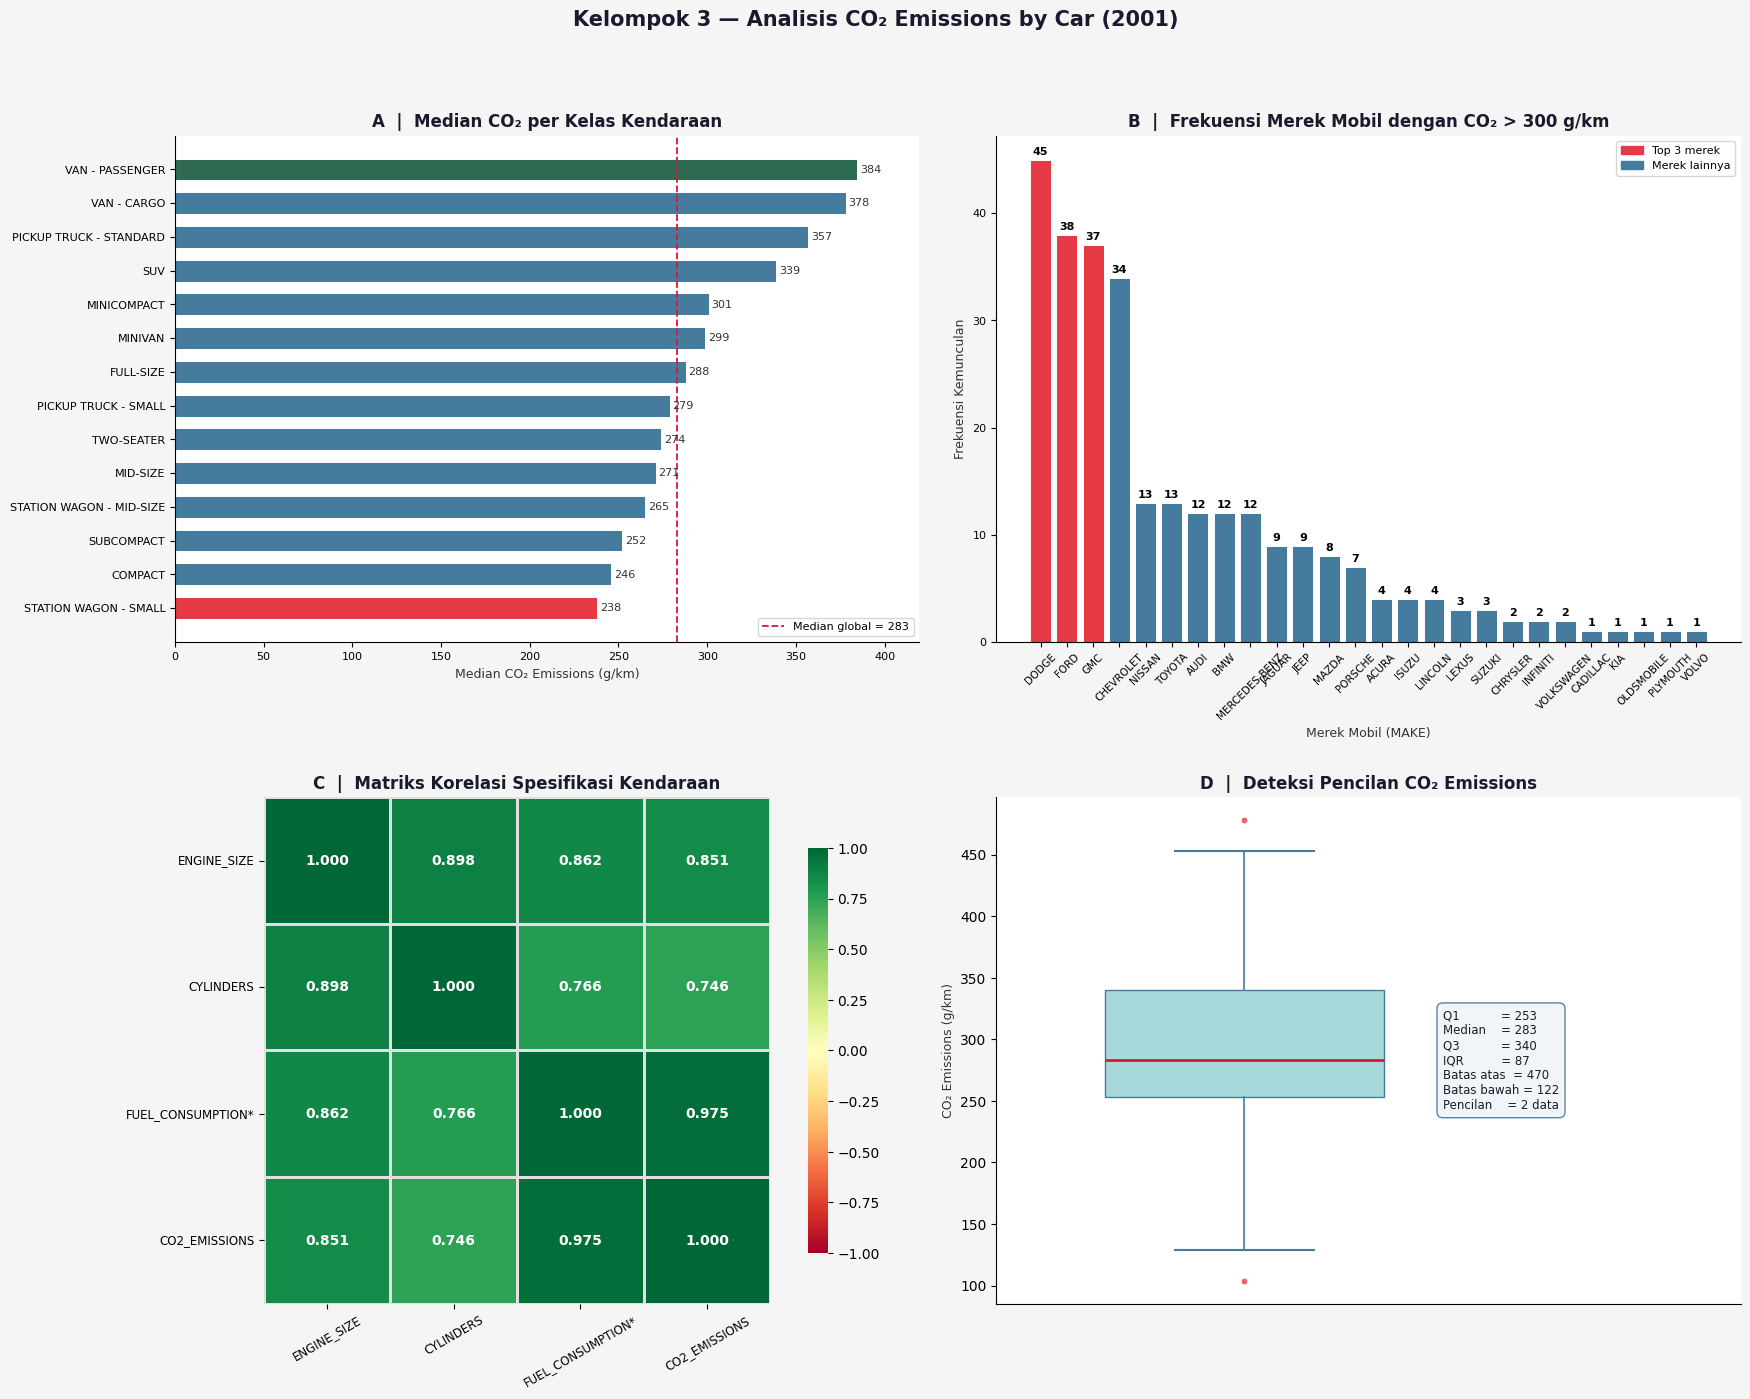

Total data     : 679
Q1             : 253
Q3             : 340
IQR            : 87
Batas bawah    : 122
Batas atas     : 470
Jumlah pencilan: 2
Nilai pencilan :
343    104
316    478


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(r"C:\Users\Lenovo\Documents\Rafif Coding\Kelas B_CO2 Emissions by Car.csv", sep=';')

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#f5f5f5')

# ── Styling global ──────────────────────────────────────────
TITLE_FONT  = {'fontsize': 12, 'fontweight': 'bold', 'color': '#1a1a2e'}
LABEL_FONT  = {'fontsize': 9,  'color': '#333333'}
ACCENT      = '#2d6a4f'
ACCENT2     = '#e63946'
ACCENT3     = '#457b9d'
BG_AX       = '#ffffff'

# ─────────────────────────────────────────────────────────────
# KOLOM A — Median CO2 per VEHICLE CLASS → Horizontal Bar Chart
# ─────────────────────────────────────────────────────────────
ax_a = fig.add_subplot(2, 2, 1)
ax_a.set_facecolor(BG_AX)

median_co2 = (df.groupby('VEHICLE CLASS')['CO2_EMISSIONS']
                .median()
                .sort_values(ascending=True))

colors_a = [ACCENT  if v == median_co2.max() else
            ACCENT2 if v == median_co2.min() else
            ACCENT3 for v in median_co2.values]

bars = ax_a.barh(median_co2.index, median_co2.values,
                 color=colors_a, edgecolor='white', linewidth=0.7, height=0.65)

for bar, val in zip(bars, median_co2.values):
    ax_a.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
              f'{int(val)}', va='center', ha='left', fontsize=8, color='#333')

global_median = df['CO2_EMISSIONS'].median()
ax_a.axvline(global_median, color='crimson', linestyle='--', linewidth=1.3,
             label=f'Median global = {int(global_median)}')

ax_a.set_xlabel('Median CO₂ Emissions (g/km)', **LABEL_FONT)
ax_a.set_title('A  |  Median CO₂ per Kelas Kendaraan', **TITLE_FONT)
ax_a.legend(fontsize=8)
ax_a.spines[['top', 'right']].set_visible(False)
ax_a.tick_params(labelsize=8)
ax_a.set_xlim(0, median_co2.max() + 35)

# ─────────────────────────────────────────────────────────────
# KOLOM B — Filter MAKE dengan CO2 > 300, frekuensi → Bar Chart
# ─────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(2, 2, 2)
ax_b.set_facecolor(BG_AX)

df_high   = df[df['CO2_EMISSIONS'] > 300]
freq_make = df_high['MAKE'].value_counts().sort_values(ascending=False)

palette_b = [ACCENT2 if i < 3 else ACCENT3 for i in range(len(freq_make))]
bars_b = ax_b.bar(freq_make.index, freq_make.values,
                  color=palette_b, edgecolor='white', linewidth=0.7)

for bar, val in zip(bars_b, freq_make.values):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_b.set_xlabel('Merek Mobil (MAKE)', **LABEL_FONT)
ax_b.set_ylabel('Frekuensi Kemunculan', **LABEL_FONT)
ax_b.set_title('B  |  Frekuensi Merek Mobil dengan CO₂ > 300 g/km', **TITLE_FONT)
ax_b.tick_params(axis='x', rotation=45, labelsize=7.5)
ax_b.tick_params(axis='y', labelsize=8)
ax_b.spines[['top', 'right']].set_visible(False)

top3 = mpatches.Patch(color=ACCENT2, label='Top 3 merek')
rest = mpatches.Patch(color=ACCENT3, label='Merek lainnya')
ax_b.legend(handles=[top3, rest], fontsize=8)

# ─────────────────────────────────────────────────────────────
# KOLOM C — Matriks korelasi numerik → Heatmap
# ─────────────────────────────────────────────────────────────
ax_c = fig.add_subplot(2, 2, 3)
ax_c.set_facecolor(BG_AX)

num_cols = ['ENGINE_SIZE', 'CYLINDERS', 'FUEL_CONSUMPTION*', 'CO2_EMISSIONS']
corr_mat = df[num_cols].corr()

sns.heatmap(corr_mat, annot=True, fmt='.3f', ax=ax_c,
            cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.8, linecolor='#e0e0e0',
            annot_kws={'size': 10, 'weight': 'bold'},
            square=True, cbar_kws={'shrink': 0.8})

ax_c.set_title('C  |  Matriks Korelasi Spesifikasi Kendaraan', **TITLE_FONT)
ax_c.tick_params(axis='x', rotation=30, labelsize=8.5)
ax_c.tick_params(axis='y', rotation=0,  labelsize=8.5)

# ─────────────────────────────────────────────────────────────
# KOLOM D — Deteksi pencilan CO2_EMISSIONS → Boxplot
# ─────────────────────────────────────────────────────────────
ax_d = fig.add_subplot(2, 2, 4)
ax_d.set_facecolor(BG_AX)

co2 = df['CO2_EMISSIONS']
Q1      = co2.quantile(0.25)
Q3      = co2.quantile(0.75)
IQR     = Q3 - Q1
lower   = Q1 - 1.5 * IQR
upper   = Q3 + 1.5 * IQR
outliers = co2[(co2 < lower) | (co2 > upper)]

ax_d.boxplot(co2, vert=True, patch_artist=True, widths=0.45,
             boxprops=dict(facecolor='#a8dadc', color=ACCENT3),
             medianprops=dict(color='crimson', linewidth=2),
             whiskerprops=dict(color=ACCENT3, linewidth=1.2),
             capprops=dict(color=ACCENT3, linewidth=1.5),
             flierprops=dict(marker='o', markerfacecolor=ACCENT2,
                             markersize=5, linestyle='none',
                             markeredgecolor='white', alpha=0.8))

stats_text = (f'Q1           = {Q1:.0f}\n'
              f'Median    = {co2.median():.0f}\n'
              f'Q3           = {Q3:.0f}\n'
              f'IQR          = {IQR:.0f}\n'
              f'Batas atas  = {upper:.0f}\n'
              f'Batas bawah = {lower:.0f}\n'
              f'Pencilan    = {len(outliers)} data')
ax_d.text(1.32, co2.median(), stats_text, va='center', ha='left',
          fontsize=8.5, color='#1a1a2e',
          bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4f8',
                    edgecolor=ACCENT3, alpha=0.9))

ax_d.set_ylabel('CO₂ Emissions (g/km)', **LABEL_FONT)
ax_d.set_xticks([])
ax_d.set_title('D  |  Deteksi Pencilan CO₂ Emissions', **TITLE_FONT)
ax_d.spines[['top', 'right']].set_visible(False)
ax_d.set_xlim(0.6, 1.8)

# ── Judul utama ──────────────────────────────────────────────
fig.suptitle('Kelompok 3 — Analisis CO₂ Emissions by Car (2001)',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01)

plt.tight_layout(pad=2.5)
plt.savefig('kelompok3_CO2.png', dpi=160, bbox_inches='tight', facecolor='#f5f5f5')
plt.show()

# ── Print ringkasan pencilan ─────────────────────────────────
print("=" * 40)
print(f"Total data     : {len(df)}")
print(f"Q1             : {Q1:.0f}")
print(f"Q3             : {Q3:.0f}")
print(f"IQR            : {IQR:.0f}")
print(f"Batas bawah    : {lower:.0f}")
print(f"Batas atas     : {upper:.0f}")
print(f"Jumlah pencilan: {len(outliers)}")
print("Nilai pencilan :")
print(outliers.sort_values().to_string())
print("=" * 40)